# 01 - EDA & Data Cleaning
**Dataset:** UCI Online Retail II  
**Goal:** Understand the data, handle missing values, duplicates, returns, and save a clean version for downstream use.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style = "whitegrid")
plt.rcParams["figure.dpi"] = 120

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [4]:
df = pd.read_csv('../data/raw/online_retail_II.csv', encoding='utf-8')

print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Shape: (1067371, 8)
Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## 1. Basic Overview

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  str    
 1   StockCode    1067371 non-null  str    
 2   Description  1062989 non-null  str    
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  str    
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 65.1 MB


## 2. Missing Values

In [6]:
missing = df.isnull().sum()
missing_percent = ((missing / len(df)) * 100).round(2)
pd.DataFrame({"Missing Count": missing, "Missing %": missing_percent})

,Missing Count,Missing %
Invoice,0,0.00
StockCode,0,0.00
Description,4382,0.41
Quantity,0,0.00
InvoiceDate,0,0.00
Price,0,0.00
Customer ID,243007,22.77
Country,0,0.00


## 3. Duplicates

In [7]:
print(f"Duplicates row: {df.duplicated().sum()}")

Duplicates row: 34335


## 4. Descriptive Statistics

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Quantity,1067371.0,9.938898,172.705794,-80995.00,1.00,3.0,10.00,80995.0
Price,1067371.0,4.649388,123.553059,-53594.36,1.25,2.1,4.15,38970.0
Customer ID,824364.0,15324.638504,1697.464450,12346.00,13975.00,15255.0,16797.00,18287.0


## 5. Key Observations
- `Customer ID` has 22.77% missing values — rows dropped as anonymous transactions can't be segmented
- `Description` has 0.41% missing — will be dropped along with Customer ID nulls
- 34,335 duplicate rows found — will be removed
- Negative `Quantity` and `Price` values indicate returns/cancellations — will be filtered out
- `InvoiceDate` is currently a string — needs to be parsed to datetime

## 6. Data Cleaning

In [10]:
# Drop missing Customer IDs
df = df.dropna(subset=['Customer ID'])

# Drop duplicates
df = df.drop_duplicates()

# Remove returns/cancellations (negative quantities or price)
df = df[df['Quantity'] > 0]
df = df[df['Price'] > 0]

# Remove cancelled invoices (start with 'C')
df = df[~df['Invoice'].astype(str).str.startswith('C')]

# Parse InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Fix Customer ID to dtype
df['Customer ID'] = df['Customer ID'].astype(int)

print(f"Cleaned Shape: {df.shape}")
df.head()

Cleaned Shape: (779425, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom


## 7. Feature: TotalPrice
Adding revenue column needed for EDA.

In [11]:
df['TotalPrice'] = df['Quantity'] * df['Price']
print(f"TotalPrice range: {df['TotalPrice'].min():.2f} - {df['TotalPrice'].max():.2f}")

TotalPrice range: 0.00 - 168469.60


## 8. Exploratory Data Analysis

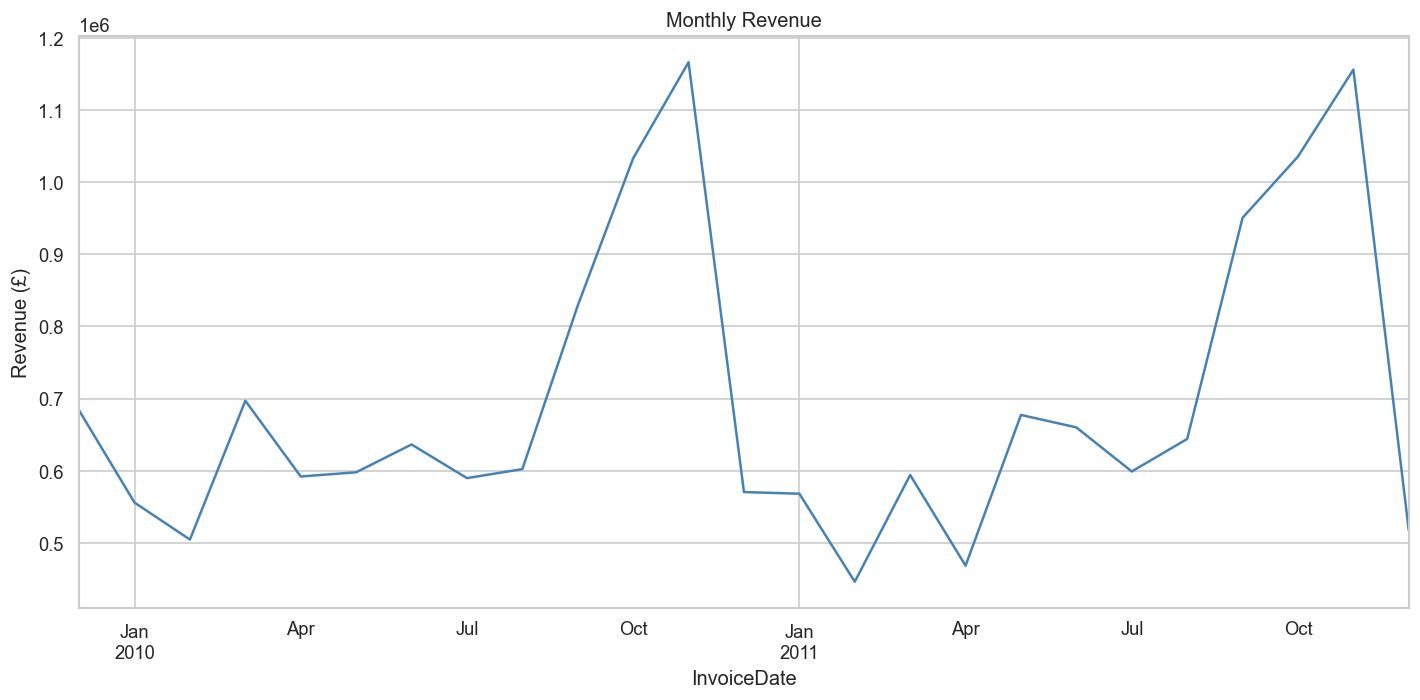

In [15]:
df.set_index('InvoiceDate').resample('ME')['TotalPrice'].sum().plot(figsize=(12, 6), title='Monthly Revenue', color='steelblue')
plt.ylabel('Revenue (£)')
plt.tight_layout()
plt.savefig('../reports/figures/monthly_revenue.png')
plt.show()

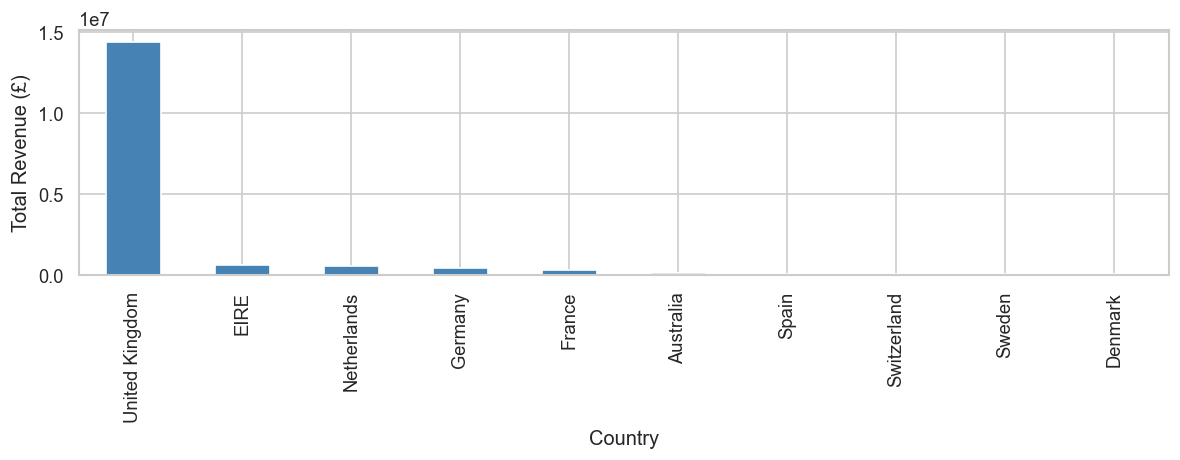

In [17]:
top_countries = (df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10))
top_countries.plot(kind='bar', figsize=(10, 4), color='steelblue')
plt.ylabel('Total Revenue (£)')
plt.tight_layout()
plt.savefig('../reports/figures/top_countries.png')
plt.show()

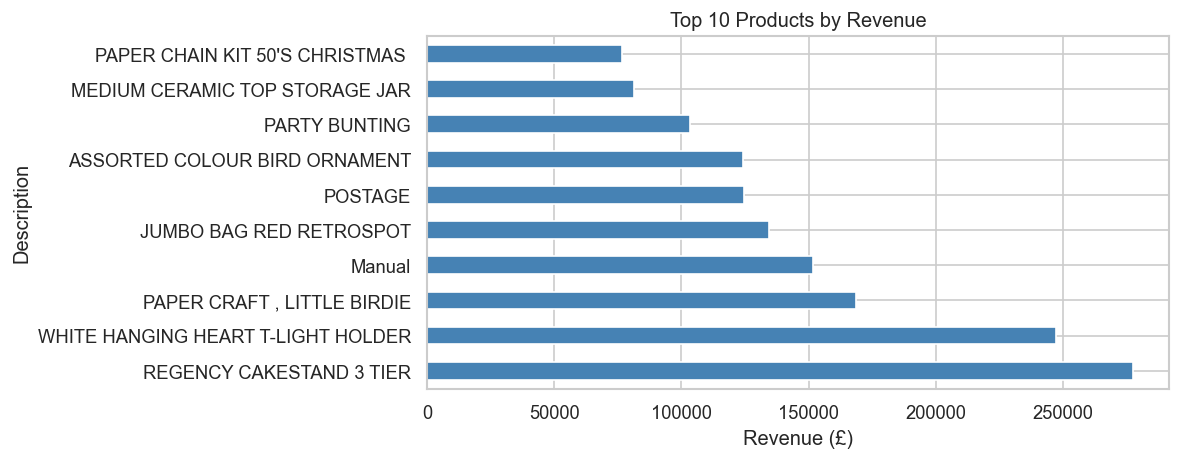

In [18]:
top_products = (df.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False).head(10))

top_products.plot(kind='barh', figsize=(10, 4), title='Top 10 Products by Revenue', color='steelblue')
plt.xlabel('Revenue (£)')
plt.tight_layout()
plt.savefig('../reports/figures/top_products.png')
plt.show()

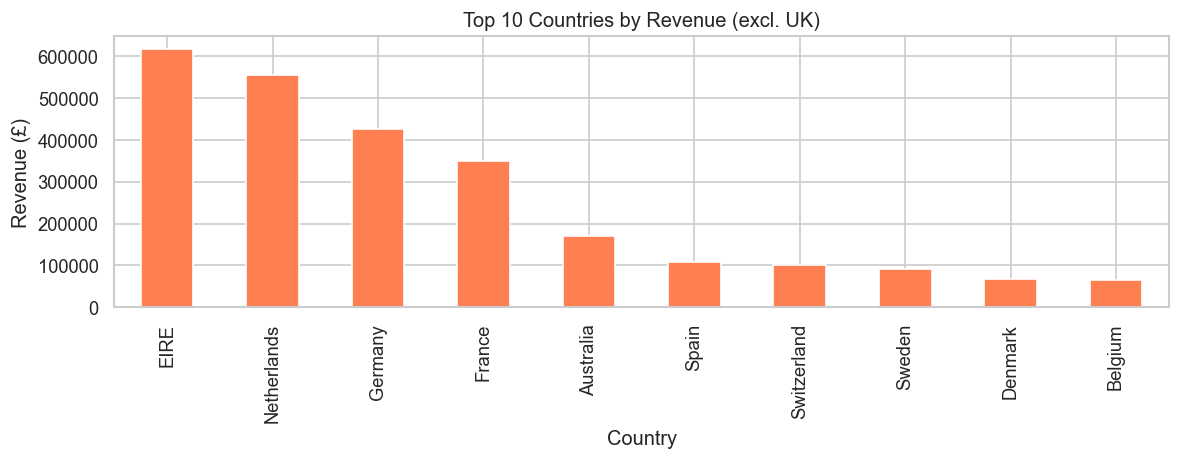

In [19]:
orders_ex_uk = (df[df['Country'] != 'United Kingdom'].groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10))

orders_ex_uk.plot(kind='bar', figsize=(10, 4), title='Top 10 Countries by Revenue (excl. UK)', color='coral')
plt.ylabel('Revenue (£)')
plt.tight_layout()
plt.savefig('../reports/figures/top_countries_ex_uk.png')
plt.show()

## 9. EDA Observations
- Strong seasonality: revenue peaks every November (Christmas season), drops sharply in December (likely incomplete data)
- UK dominates revenue (~£14.5M), accounting for ~85% of total sales
- Top international markets: EIRE, Netherlands, Germany, France
- Top products are gifting/home décor items — consistent with a seasonal gifting retailer
- Non-product entries found in Description ('Manual', 'POSTAGE') — flagged for removal

In [20]:
# Remove non-product entries
non_products = ['Manual', 'POSTAGE', 'DOT COM POSTAGE', 'BANK CHARGES']
df = df[~df['Description'].isin(non_products)]

print(f"Shape after removing non-products: {df.shape}")

Shape after removing non-products: (776941, 9)


## 10. Unique Customers & Orders Over Time

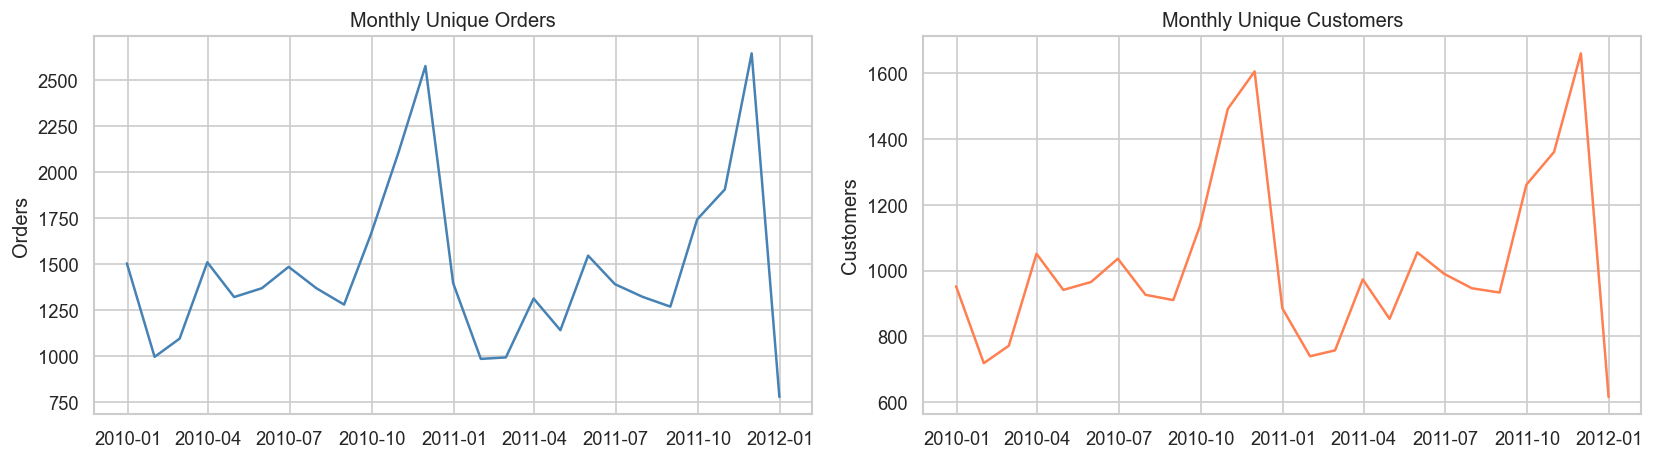

In [21]:
monthly = df.resample('ME', on='InvoiceDate').agg(
    Revenue=('TotalPrice', 'sum'),
    Orders=('Invoice', 'nunique'),
    Customers=('Customer ID', 'nunique')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(monthly['InvoiceDate'], monthly['Orders'], color='steelblue')
axes[0].set_title('Monthly Unique Orders')
axes[0].set_ylabel('Orders')

axes[1].plot(monthly['InvoiceDate'], monthly['Customers'], color='coral')
axes[1].set_title('Monthly Unique Customers')
axes[1].set_ylabel('Customers')

plt.tight_layout()
plt.savefig('../reports/figures/monthly_orders_customers.png')
plt.show()

In [ ]:
# Drop missing Customer IDs
df = df.dropna(subset=['Customer ID'])

# Drop duplicates
df = df.drop_duplicates()

# Remove returns/cancellations (negative quantities or price)
df = df[df['Quantity'] > 0]
df = df[df['Price'] > 0]

# Remove cancelled invoices (start with 'C')
df = df[~df['Invoice'].astype(str).str.startswith('C')]

# Parse InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Fix Customer ID to dtype
df['Customer ID'] = df['Customer ID'].astype(int)

print(f"Cleaned Shape: {df.shape}")
df.head()

Cleaned Shape: (779425, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom


## 12. What Do Customers Buy? — Product Analysis

### 12.1 Pareto Analysis — Which products drive 80% of revenue?

Top 1151 products (21.8% of catalogue) drive 80% of revenue


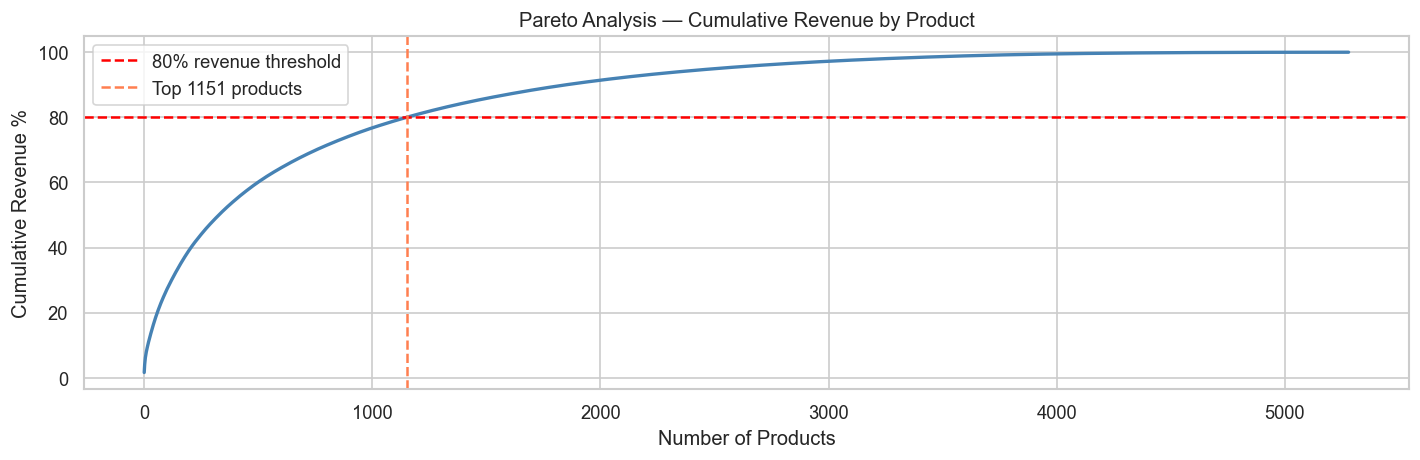

In [22]:
product_revenue = (df.groupby('Description')['TotalPrice']
                   .sum()
                   .sort_values(ascending=False)
                   .reset_index())

product_revenue['cumulative_pct'] = (product_revenue['TotalPrice'].cumsum() 
                                      / product_revenue['TotalPrice'].sum() * 100)

cutoff = product_revenue[product_revenue['cumulative_pct'] <= 80].shape[0]
total = product_revenue.shape[0]

print(f"Top {cutoff} products ({(cutoff/total*100):.1f}% of catalogue) drive 80% of revenue")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(range(len(product_revenue)), product_revenue['cumulative_pct'], color='steelblue', lw=2)
ax.axhline(80, color='red', linestyle='--', label='80% revenue threshold')
ax.axvline(cutoff, color='coral', linestyle='--', label=f'Top {cutoff} products')
ax.set_xlabel('Number of Products')
ax.set_ylabel('Cumulative Revenue %')
ax.set_title('Pareto Analysis — Cumulative Revenue by Product')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/pareto_products.png')
plt.show()

### Insight
Out of ~5,400 unique products, just **1,151 (~21%) drive 80% of total revenue** — a clear Pareto effect.
This suggests the business can focus marketing and inventory efforts on a relatively small core catalogue.

## 13. Where Are Our Customers? — Geographic Analysis

In [28]:
country_revenue = (df.groupby('Country')['TotalPrice']
                   .sum()
                   .reset_index()
                   .rename(columns={'TotalPrice': 'Revenue'}))

country_revenue['Country'] = country_revenue['Country'].replace({'EIRE': 'Ireland'})

import plotly.express as px

fig = px.choropleth(
    country_revenue,
    locations='Country',
    locationmode='country names',
    color='Revenue',
    color_continuous_scale='Blues',
    title='Global Revenue Distribution',
    labels={'Revenue': 'Revenue (£)'}
)

fig.update_layout(
    geo=dict(showframe=False, showcoastlines=True),
    width=900, height=500
)

fig.show()

### Insight
Revenue is heavily concentrated in the **United Kingdom (~£14.5M)**, with Western Europe
(Ireland, Netherlands, Germany, France) as the only meaningful international markets.
This is essentially a UK-first business with limited but present global reach.

## 14. Who Are Our Customers? — Customer Behaviour

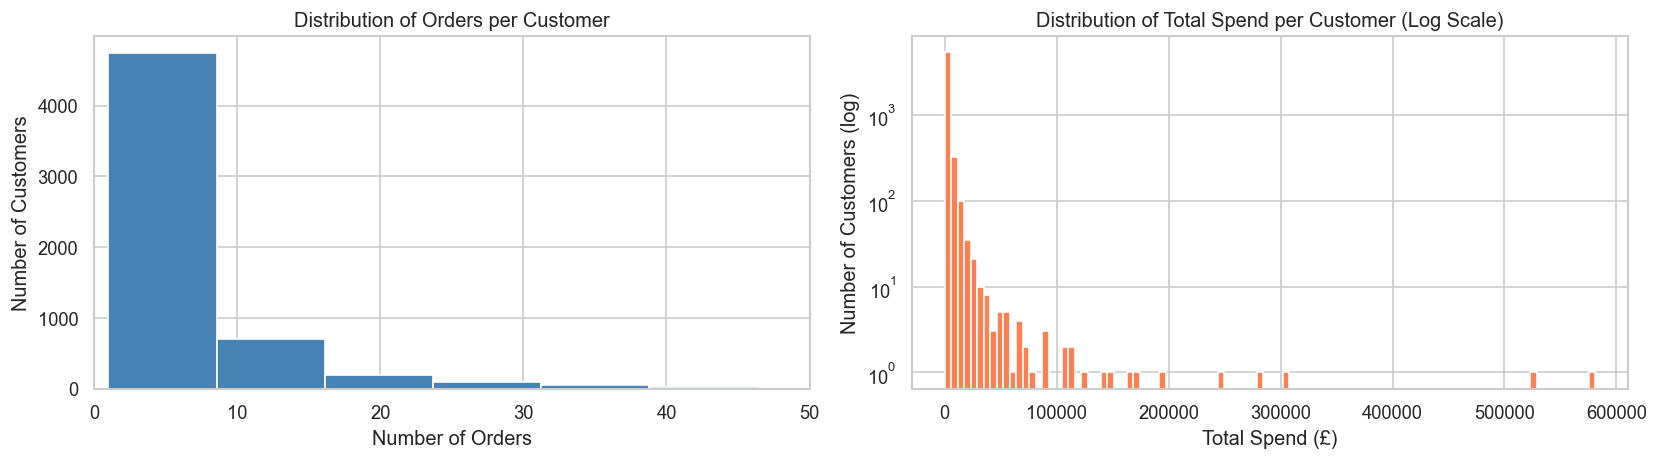

Customers with only 1 order: 1626 (27.7%)
Median orders per customer: 3.0
Median spend per customer: £855.22


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(orders_per_customer, bins=50, color='steelblue', edgecolor='white')
axes[0].set_xlim(0, 50)
axes[0].set_title('Distribution of Orders per Customer')
axes[0].set_xlabel('Number of Orders')
axes[0].set_ylabel('Number of Customers')

axes[1].hist(spend_per_customer, bins=100, color='coral', edgecolor='white', log=True)
axes[1].set_title('Distribution of Total Spend per Customer (Log Scale)')
axes[1].set_xlabel('Total Spend (£)')
axes[1].set_ylabel('Number of Customers (log)')

plt.tight_layout()
plt.savefig('../reports/figures/customer_distributions.png')
plt.show()

print(f"Customers with only 1 order: {(orders_per_customer == 1).sum()} ({(orders_per_customer == 1).mean()*100:.1f}%)")
print(f"Median orders per customer: {orders_per_customer.median()}")
print(f"Median spend per customer: £{spend_per_customer.median():.2f}")

### Insight
- **27.7% of customers placed only 1 order** — a significant one-time buyer segment worth targeting for re-engagement
- Median customer places **3 orders** and spends **£855** — suggesting a healthy repeat purchase rate overall
- Both distributions are heavily right-skewed — a small number of high-value, high-frequency customers drive disproportionate revenue
- Spend extends up to **£600,000** for some customers — likely **wholesale/B2B buyers** mixed in with retail customers
- This skew is exactly **why segmentation is needed** — treating all customers the same would be a mistake

## 15. When Do Customers Buy? — Time & Seasonality

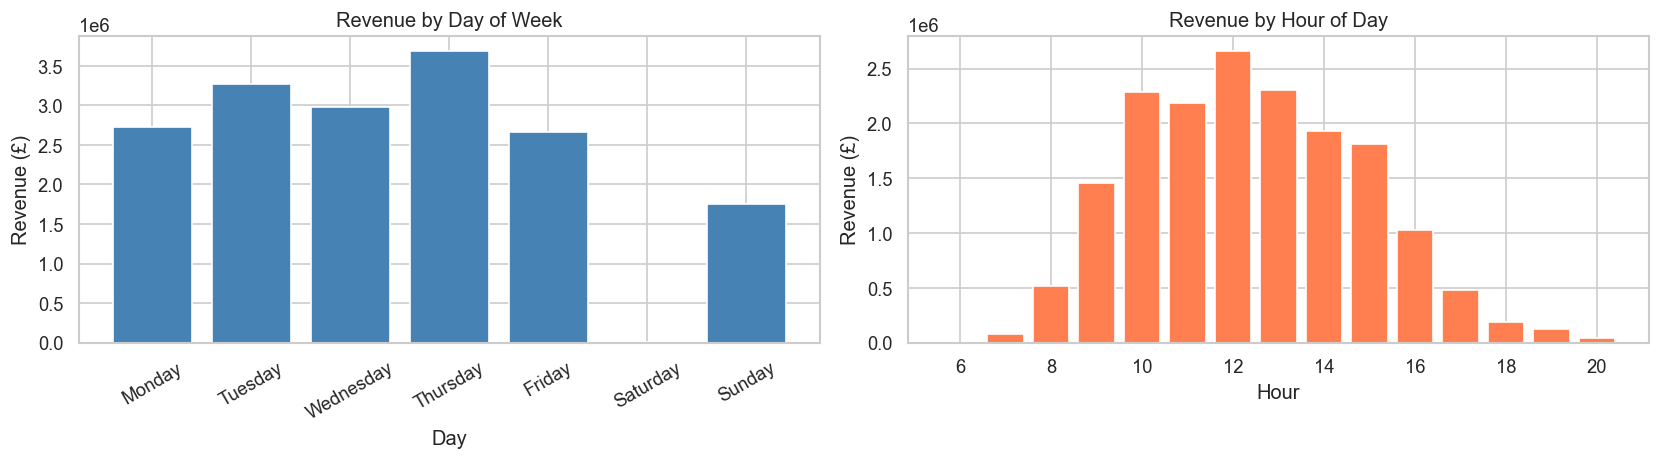

In [32]:
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()
df['Hour'] = df['InvoiceDate'].dt.hour

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

revenue_by_day = df.groupby('DayOfWeek')['TotalPrice'].sum().reindex(day_order)
revenue_by_hour = df.groupby('Hour')['TotalPrice'].sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(day_order, revenue_by_day, color='steelblue', edgecolor='white')
axes[0].set_title('Revenue by Day of Week')
axes[0].set_xlabel('Day')
axes[0].set_ylabel('Revenue (£)')
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(revenue_by_hour.index, revenue_by_hour, color='coral', edgecolor='white')
axes[1].set_title('Revenue by Hour of Day')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Revenue (£)')

plt.tight_layout()
plt.savefig('../reports/figures/revenue_day_hour.png')
plt.show()

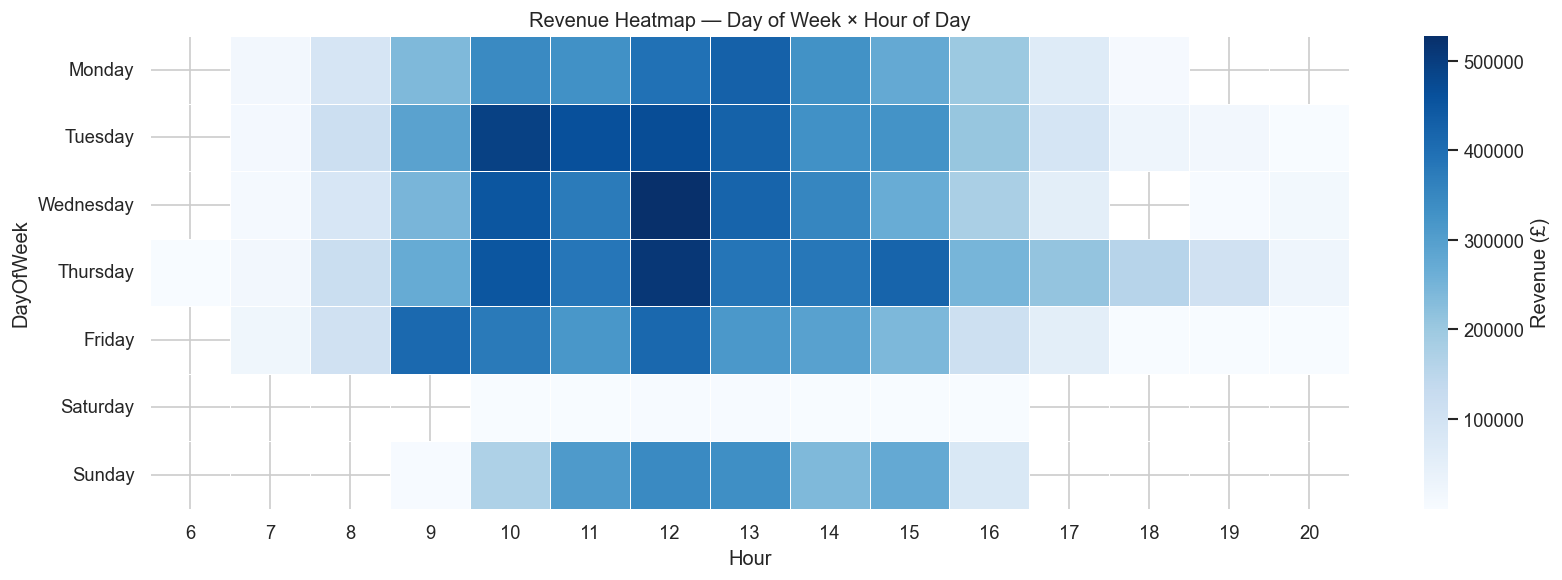

In [33]:
pivot = df.pivot_table(index='DayOfWeek', columns='Hour', 
                        values='TotalPrice', aggfunc='sum')
pivot = pivot.reindex(day_order)

plt.figure(figsize=(14, 5))
sns.heatmap(pivot, cmap='Blues', linewidths=0.5, fmt='.0f',
            cbar_kws={'label': 'Revenue (£)'})
plt.title('Revenue Heatmap — Day of Week × Hour of Day')
plt.tight_layout()
plt.savefig('../reports/figures/revenue_heatmap.png')
plt.show()

### Insight
- **Thursday is the busiest day**, Saturday has near-zero activity — suggesting this is a B2B-oriented business operating on a standard business week
- **Peak shopping hours are 10am–1pm**, with activity dropping sharply after 5pm — no late-night consumer shopping behaviour
- The **Tue–Thu, 10am–1pm window** is the highest revenue zone, confirmed by the heatmap
- This strongly suggests the customer base is **predominantly wholesale/trade buyers** rather than individual consumers

## 16. Are Customers Coming Back? — Retention Snapshot

Customers in 2010 only:  1560
Customers in 2011 only:  1557
Retained (both years):   2657
Retention rate: 63.0%


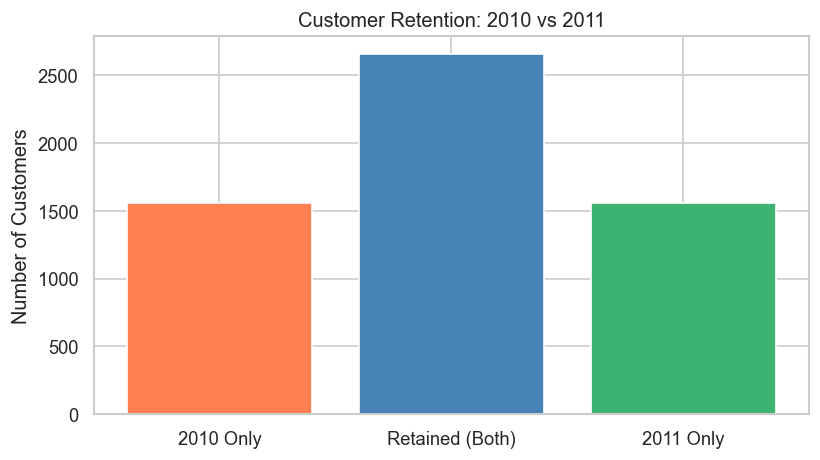

In [34]:
df['Year'] = df['InvoiceDate'].dt.year

customers_2010 = set(df[df['Year'] == 2010]['Customer ID'].unique())
customers_2011 = set(df[df['Year'] == 2011]['Customer ID'].unique())

only_2010 = len(customers_2010 - customers_2011)
only_2011 = len(customers_2011 - customers_2010)
both = len(customers_2010 & customers_2011)

print(f"Customers in 2010 only:  {only_2010}")
print(f"Customers in 2011 only:  {only_2011}")
print(f"Retained (both years):   {both}")
print(f"Retention rate: {both/len(customers_2010)*100:.1f}%")

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(['2010 Only', 'Retained (Both)', '2011 Only'], 
       [only_2010, both, only_2011],
       color=['coral', 'steelblue', 'mediumseagreen'], edgecolor='white')
ax.set_title('Customer Retention: 2010 vs 2011')
ax.set_ylabel('Number of Customers')
plt.tight_layout()
plt.savefig('../reports/figures/retention_snapshot.png')
plt.show()

### Insight
- **63% of 2010 customers returned in 2011** — a strong retention rate, typical of a loyal wholesale/trade customer base
- ~1,560 customers were lost after 2010 — a key re-engagement opportunity
- ~1,557 new customers acquired in 2011 — roughly replacing the churned ones
- This near-equal churn vs acquisition suggests the business is in a **steady state** rather than growing its customer base
- **Segmentation becomes critical here** — which retained customers are high value? Which churned customers were worth recovering?

## 17. EDA Summary — The Story So Far

| Theme | Key Finding |
|-------|-------------|
| **Revenue** | Strong seasonality — peaks every November, drops in December |
| **Geography** | UK-dominant (~85% revenue), Western Europe is the only meaningful international market |
| **Products** | Top 21% of products drive 80% of revenue — clear Pareto effect |
| **Customers** | 27.7% one-time buyers, median spend £855, heavy right skew suggesting B2B wholesale buyers |
| **Timing** | Peak activity Thu 10am–1pm, zero Saturday — classic B2B business hours |
| **Retention** | 63% year-on-year retention — healthy but ~1,560 customers churned |

### Why Segmentation?
Customers range from one-time low-spend buyers to high-value wholesale regulars spending £600K+.
A one-size-fits-all marketing strategy would fail this customer base.
**RFM-based segmentation will allow us to treat each customer group appropriately.**

## 18. Save Cleaned Data

In [37]:
df.to_csv('../data/processed/retail_cleaned.csv', index=False)
print(f"Saved: {df.shape}")
print(f"Date range: {df['InvoiceDate'].min()} → {df['InvoiceDate'].max()}")
print(f"Unique customers: {df['Customer ID'].nunique()}")
print(f"Unique products: {df['StockCode'].nunique()}")

Saved: (776941, 12)
Date range: 2009-12-01 07:45:00 → 2011-12-09 12:50:00
Unique customers: 5862
Unique products: 4629
